### What this notebook does

| Item | Description |
|---|---|
| Input | `screening_results.pkl` — per-condition, per-seed feature lists |
| | `labeled_splits.pkl` / `kmeans_labeled_splits.pkl` — threshold derived from seed-42, applied uniformly |
| | `threshold_log.pkl` / `kmeans_threshold_log.pkl` — thresholds for all 10 label seeds |
| Samples | **Early + Intermediate only** (Label ≠ 1; Late excluded) |
| Target | TPC (log CFU/g) — continuous regression |
| Models | LightGBM, Random Forest, XGBoost, SVR, LSTM — 5 algorithms |
| Tuning | GridSearchCV, cv = 5, scoring = neg_mean_absolute_error |
| Iterations (main) | 4 conditions × 10 train seeds × 5 models |
| Iterations (sensitivity) | Best condition × 10 label seeds × 10 train seeds |
| Evaluation | Mean ± SD of test R², MAE, and RMSE across seeds |

### Four Conditions

| Condition | Labeling threshold | Feature Selection |
|---|---|---|
| 1 | Optuna | Fold-change Top 10 |
| 2 | Optuna | VIP ≥ 1.0 |
| 3 | K-means | Fold-change Top 10 |
| 4 | K-means | VIP ≥ 1.0 |

### Figure Plan

| Target | Description |
|---|---|
| **Main figure** | Seed-42 — best model per condition: Actual vs. Predicted scatter |
| **Supplementary** | All 10 seeds — best model per-seed scatter |
| **Sensitivity** | 10 label seeds × 10 train seeds — R² / MAE boxplot |

## Algorithm Selection Rationale

> Note for Methods section

| Algorithm | Rationale |
|---|---|
| **LightGBM** | Gradient boosting; fast and robust on small tabular datasets; leaf-wise splitting enables easier overfitting control compared to RF and XGBoost. |
| **Random Forest** | Nonlinear ensemble; robust to high feature collinearity common in microbiome data; no scaling required; low variance. |
| **XGBoost** | Gradient boosting with built-in L1/L2 regularization and automatic missing-value handling; consistently strong performance on tabular regression tasks. |
| **SVR (RBF kernel)** | Margin-based regression robust to outliers in high-dimensional, small-sample settings; StandardScaler required → wrapped in a Pipeline. |
| **LSTM** | Selected to capture monotonic trends in microbial load across storage days, leveraging sequential learning in which earlier temporal patterns inform prediction at later timepoints. |

All models tuned via GridSearchCV (cv = 5, scoring = neg_mean_absolute_error) with random_state = 42.

## ⚠️ Reproducibility Notice

> **Internal note — not included in the paper.** LSTM results may vary slightly across runs due to hardware-level floating-point non-determinism; all reported values are fixed to the stored PKL output.

### Reference values
All results in this notebook are based on **values stored in `regression_results.pkl`**.
The PKL file was generated on the initial run; all downstream analyses (SHAP, visualization, performance tables) load from this file.

### Per-model reproducibility

| Model | Reproducibility | Notes |
|---|---|---|
| **Random Forest** | ✅ Fully reproducible | `random_state=42` |
| **XGBoost** | ✅ Fully reproducible | `random_state=42` |
| **SVR** | ✅ Fully reproducible | Deterministic algorithm |
| **LightGBM** | ✅ Effectively reproducible | `random_state=42`; bagging disabled (`bagging_freq=0` default) — bagging non-determinism does not apply. Theoretical floating-point ordering differences from multi-threaded histogram building have no practical impact. |
| **LSTM** | ⚠️ Minor variation possible | Full reproducibility achievable via `tf.config.experimental.enable_op_determinism()`, but requires execution at the top of the notebook. Current results are fixed to stored PKL values. |

### Final selected model
The final model reported in this paper (Random Forest) is fully reproducible; stored PKL values match re-execution results exactly.

## 1. Data Load

- `screening_results.pkl` — per-condition, per-seed feature lists (train-only feature selection)
- `labeled_splits.pkl` — Optuna-based labels; threshold derived from seed-42 and applied uniformly across 10 train seeds
- `kmeans_labeled_splits.pkl` — K-means-based labels; same fixed-threshold approach across 10 train seeds
- `threshold_log.pkl` — Optuna thresholds independently fit for all 10 label seeds (used in Section 11 sensitivity analysis)
- `kmeans_threshold_log.pkl` — K-means thresholds independently fit for all 10 label seeds (used in Section 11 sensitivity analysis)

Early + Intermediate filter: `Label != 1` (Early = 0, Late = 1, Intermediate = 2)  
Regression target: `tpc_col` (TPC, log CFU/g)

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn.base as _base

import tensorflow as tf
from sklearn.base import BaseEstimator, RegressorMixin

CODE_DIR = "/home/admin-01/taeho/BRL_chicken/revision/code"
DATA_DIR = f"{CODE_DIR}/data"
PKL_DIR  = f"{DATA_DIR}/pkl"
REG_DIR  = f"{DATA_DIR}/reg_scatter"
os.makedirs(REG_DIR, exist_ok=True)

SEEDS      = [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
LABEL_SEED = 42

C_TRAIN = '#1f77b4'
C_TEST  = '#ff7f0e'

MODEL_SHORT = {
    'LightGBM':     'LGB',
    'RandomForest': 'RF',
    'XGBoost':      'XGB',
    'SVR':          'SVR',
}
COND_LABELS = {
    'cond1': 'Optuna × FC Top10',
    'cond2': 'Optuna × VIP≥1.0',
    'cond3': 'K-means × FC Top10',
    'cond4': 'K-means × VIP≥1.0',
}

I0000 00:00:1787026956.203500 1818800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787026956.414026 1818800 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787026957.166491 1818800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
with open(f"{PKL_DIR}/screening_results.pkl", "rb") as f:
    screen = pickle.load(f)
with open(f"{PKL_DIR}/labeled_splits.pkl", "rb") as f:
    optuna_data = pickle.load(f)
with open(f"{PKL_DIR}/kmeans_labeled_splits.pkl", "rb") as f:
    kmeans_data = pickle.load(f)
with open(f"{PKL_DIR}/threshold_log.pkl", "rb") as f:
    optuna_thr_log = pickle.load(f)
with open(f"{PKL_DIR}/kmeans_threshold_log.pkl", "rb") as f:
    kmeans_thr_log = pickle.load(f)

optuna_splits = optuna_data['labeled_splits']
kmeans_splits = kmeans_data['labeled_splits']
tpc_col       = optuna_data['tpc_col']

COND_MAP = {
    'cond1': (optuna_splits, 'cond1_optuna_fc10'),
    'cond2': (optuna_splits, 'cond2_optuna_vip'),
    'cond3': (kmeans_splits, 'cond3_kmeans_fc10'),
    'cond4': (kmeans_splits, 'cond4_kmeans_vip'),
}

print("tpc_col:", tpc_col)
print("screening keys:", list(screen.keys()))
print(f"threshold_log seeds: {list(optuna_thr_log.keys())}")
for cond, (sp, fkey) in COND_MAP.items():
    feats = screen[fkey]['per_seed_features'][LABEL_SEED]
    tr    = sp[LABEL_SEED]['train']
    fm    = tr[tr['Label'] != 1]
    print(f"  {COND_LABELS[cond]}: features={len(feats)}, "
          f"train FM={len(fm)} / full={len(tr)}")

tpc_col: TPC (log CFU/g)
screening keys: ['seeds', 'label_seed', 'feature_cols', 'cond1_optuna_fc10', 'cond2_optuna_vip', 'cond3_kmeans_fc10', 'cond4_kmeans_vip']
threshold_log seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  Optuna × FC Top10: features=10, train FM=161 / full=189
  Optuna × VIP≥1.0: features=23, train FM=161 / full=189
  K-means × FC Top10: features=10, train FM=128 / full=189
  K-means × VIP≥1.0: features=30, train FM=128 / full=189


## 2. Model Definitions

GridSearchCV cv=5, scoring=neg_mean_absolute_error.  
SVR → StandardScaler included in Pipeline 

In [3]:
class LSTMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=32, dropout=0.2, epochs=100,
                 batch_size=16, learning_rate=0.001, random_state=42):
        self.units         = units
        self.dropout       = dropout
        self.epochs        = epochs
        self.batch_size    = batch_size
        self.learning_rate = learning_rate
        self.random_state  = random_state

    def _build(self, n_feat):
        tf.random.set_seed(self.random_state)
        m = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(1, n_feat)),
            tf.keras.layers.LSTM(self.units, return_sequences=False),
            tf.keras.layers.Dropout(self.dropout),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(1),
        ])
        m.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate), loss='mae')
        return m

    def fit(self, X, y):
        np.random.seed(self.random_state)
        tf.random.set_seed(self.random_state)
        self.n_features_ = X.shape[1]
        self.model_ = self._build(self.n_features_)
        self.model_.fit(X.reshape(-1, 1, self.n_features_), y,
                        epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model_.predict(
            X.reshape(-1, 1, X.shape[1]), verbose=0).flatten()

In [4]:
model_configs = {
    "LightGBM": {
        "estimator": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "n_estimators":  [100, 200],
            "max_depth":     [3, 5, 7],
            "learning_rate": [0.05, 0.1],
            "num_leaves":    [20, 31],
        },
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators":      [100, 200],
            "max_depth":         [3, 5, 7],
            "min_samples_split": [2, 5],
        },
    },
    "XGBoost": {
        "estimator": XGBRegressor(random_state=42, eval_metric='mae', verbosity=0),
        "params": {
            "n_estimators":  [100, 200],
            "max_depth":     [3, 5, 7],
            "learning_rate": [0.05, 0.1],
        },
    },
    "SVR": {
        "estimator": Pipeline([('sc', StandardScaler()), ('svr', SVR())]),
        "params": {
            "svr__C":      [0.1, 1, 10],
            "svr__gamma":  ["scale", "auto"],
            "svr__kernel": ["rbf", "linear"],
        },
    },
}

model_configs['LSTM'] = {
    'estimator': LSTMRegressor(random_state=42),
    'params': {
        'units':         [32, 64],
        'dropout':       [0.1, 0.2],
        'epochs':        [100, 150],
        'learning_rate': [0.001, 0.005],
    },
}
MODEL_SHORT['LSTM'] = 'LSTM'

## 3. Training Loop

4 conditions × 10 seeds × 5 models (LightGBM, RF, XGBoost, SVR, LSTM).  
Each seed's Early + Intermediate training samples used for GridSearchCV (cv = 5); final evaluation performed on the held-out test set.  
Validation set is handled separately in `validation.ipynb`.

In [5]:
reg_results = {c: {m: {} for m in model_configs} for c in COND_MAP}

for cond, (splits, fkey) in COND_MAP.items():
    feat_dict = screen[fkey]['per_seed_features']
    print(f"\n{'='*60}")
    print(f"Condition: {COND_LABELS[cond]}")
    print('='*60)

    for seed in SEEDS:
        feats    = feat_dict[seed]
        train_df = splits[seed]['train']
        test_df  = splits[seed]['test']

        tr_fm = train_df[train_df['Label'] != 1]
        te_fm = test_df[test_df['Label'] != 1]

        X_train = tr_fm[feats].values
        y_train = tr_fm[tpc_col].values
        X_test  = te_fm[feats].values
        y_test  = te_fm[tpc_col].values

        for model_name, cfg in model_configs.items():
            est  = _base.clone(cfg['estimator'])
            grid = GridSearchCV(est, cfg['params'], cv=5,
                                scoring='neg_mean_absolute_error',
                                n_jobs=-1, refit=True)
            grid.fit(X_train, y_train)
            best = grid.best_estimator_

            y_tr_pred = best.predict(X_train)
            y_te_pred = best.predict(X_test)

            reg_results[cond][model_name][seed] = {
                'train_r2':     r2_score(y_train, y_tr_pred),
                'test_r2':      r2_score(y_test,  y_te_pred),
                'train_mae':    mean_absolute_error(y_train, y_tr_pred),
                'test_mae':     mean_absolute_error(y_test,  y_te_pred),
                'train_rmse':   np.sqrt(mean_squared_error(y_train, y_tr_pred)),
                'test_rmse':    np.sqrt(mean_squared_error(y_test,  y_te_pred)),
                'best_model':   best,
                'best_params':  grid.best_params_,
                'features':     feats,
                'n_features':   len(feats),
                'y_train':      y_train,
                'y_train_pred': y_tr_pred,
                'y_test':       y_test,
                'y_test_pred':  y_te_pred,
            }

        print(f"  seed={seed} | " +
              " | ".join(
                  f"{MODEL_SHORT[m]} R²={reg_results[cond][m][seed]['test_r2']:.3f}"
                  for m in model_configs))

print("\n학습 완료.")


Condition: Optuna × FC Top10


I0000 00:00:1787026965.725360 1818877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787026965.725360 1818884 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787026965.731359 1818891 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787026965.731920 1818883 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

  seed=38 | LGB R²=0.706 | RF R²=0.748 | XGB R²=0.683 | SVR R²=0.620 | LSTM R²=0.588


I0000 00:00:1787027013.647953 2395652 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787027013.662512 2364396 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787027013.665809 2459775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787027013.690056 2395652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical

  seed=39 | LGB R²=0.736 | RF R²=0.695 | XGB R²=0.741 | SVR R²=0.667 | LSTM R²=0.687


...

  seed=45 | LGB R²=0.409 | RF R²=0.508 | XGB R²=0.377 | SVR R²=0.381 | LSTM R²=0.221


I0000 00:00:1787028525.194033 2951630 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028525.213644 3023399 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028525.239542 2986048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028525.241180 2951630 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical

  seed=46 | LGB R²=0.461 | RF R²=0.437 | XGB R²=0.380 | SVR R²=0.353 | LSTM R²=0.373


I0000 00:00:1787028566.663420 3661835 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028566.678681 3853226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028566.678681 3852818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787028566.698348 3852817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

  seed=47 | LGB R²=0.416 | RF R²=0.424 | XGB R²=0.355 | SVR R²=0.427 | LSTM R²=0.383

학습 완료.


## 4. Results Summary

Mean ± SD across 10 seeds (test set).  
Top 5 by Test R² / Top 5 by Test MAE (lower is better).

In [6]:
rows = []
for cond in COND_MAP:
    for mn in model_configs:
        r2s   = [reg_results[cond][mn][s]['test_r2']    for s in SEEDS]
        maes  = [reg_results[cond][mn][s]['test_mae']   for s in SEEDS]
        rmses = [reg_results[cond][mn][s]['test_rmse']  for s in SEEDS]
        tr2s  = [reg_results[cond][mn][s]['train_r2']   for s in SEEDS]
        rows.append({
            'cond':           cond,
            'model_name':     mn,
            'Condition':      COND_LABELS[cond],
            'Model':          mn,
            'Test_R2_Mean':   np.mean(r2s),
            'Test_R2_Std':    np.std(r2s),
            'Test_MAE_Mean':  np.mean(maes),
            'Test_MAE_Std':   np.std(maes),
            'Test_RMSE_Mean': np.mean(rmses),
            'Test_RMSE_Std':  np.std(rmses),
            'Train_R2_Mean':  np.mean(tr2s),
            'Overfit_R2':     np.mean(tr2s) - np.mean(r2s),
        })

df_rank  = pd.DataFrame(rows)
top5_r2  = df_rank.nlargest(5,  'Test_R2_Mean').reset_index(drop=True)
top5_mae = df_rank.nsmallest(5, 'Test_MAE_Mean').reset_index(drop=True)

print("=== Top 5 by Test R² ===")
print(top5_r2[['Condition','Model','Test_R2_Mean','Test_R2_Std',
               'Test_MAE_Mean','Overfit_R2']].to_string(index=True))
print()
print("=== Top 5 by Test MAE (낮을수록 좋음) ===")
print(top5_mae[['Condition','Model','Test_R2_Mean',
                'Test_MAE_Mean','Test_MAE_Std']].to_string(index=True))

=== Top 5 by Test R² ===
           Condition         Model  Test_R2_Mean  Test_R2_Std  Test_MAE_Mean  Overfit_R2
0   Optuna × VIP≥1.0  RandomForest      0.718555     0.061167       0.431553    0.201812
1  Optuna × FC Top10  RandomForest      0.713128     0.036156       0.432962    0.141594
2   Optuna × VIP≥1.0       XGBoost      0.710500     0.059517       0.435306    0.248837
3   Optuna × VIP≥1.0      LightGBM      0.697722     0.071373       0.450897    0.226663
4   Optuna × VIP≥1.0          LSTM      0.693502     0.111193       0.450643    0.226535

=== Top 5 by Test MAE (낮을수록 좋음) ===
            Condition         Model  Test_R2_Mean  Test_MAE_Mean  Test_MAE_Std
0  K-means × FC Top10  RandomForest      0.471106       0.293639      0.034351
1   K-means × VIP≥1.0  RandomForest      0.469786       0.294811      0.037671
2  K-means × FC Top10           SVR      0.435192       0.304259      0.037452
3   K-means × VIP≥1.0      LightGBM      0.414964       0.308708      0.045381
4  K-mean

## 5. Scatter Plot (Actual vs. Predicted)

Based on the seed-42 test set.  
- Figure set 1: Top 5 by Test R²
- Figure set 2: Top 5 by Test MAE

Each figure saved individually → `data/reg_scatter/`

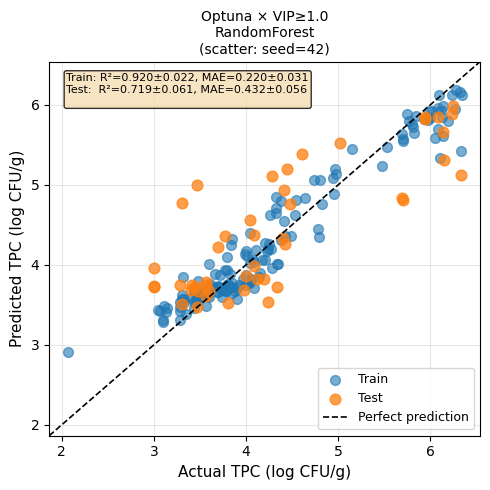

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5r2_cond2_RF_scatter.png


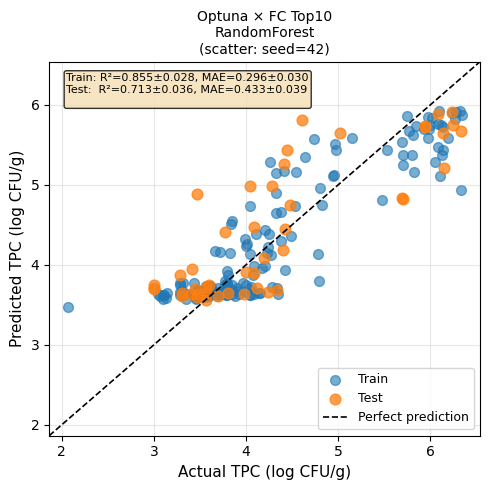

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5r2_cond1_RF_scatter.png


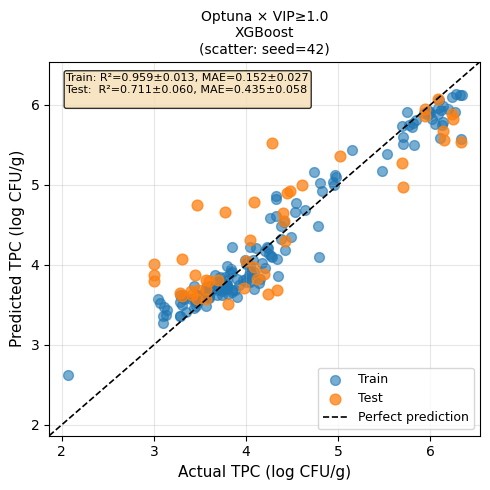

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5r2_cond2_XGB_scatter.png


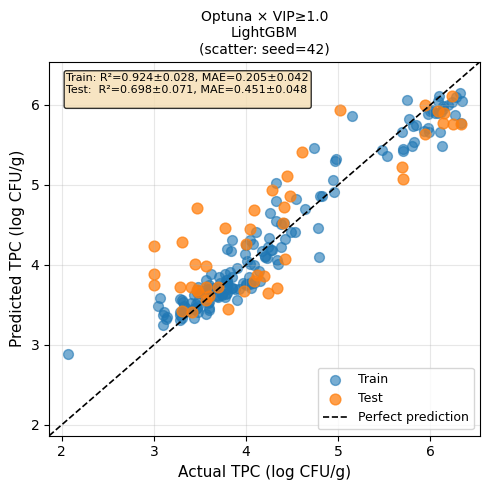

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5r2_cond2_LGB_scatter.png


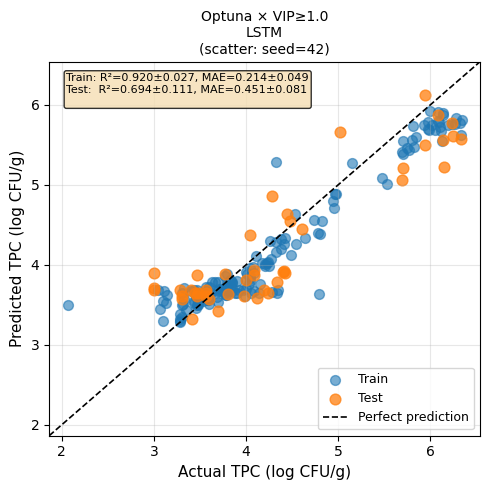

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5r2_cond2_LSTM_scatter.png


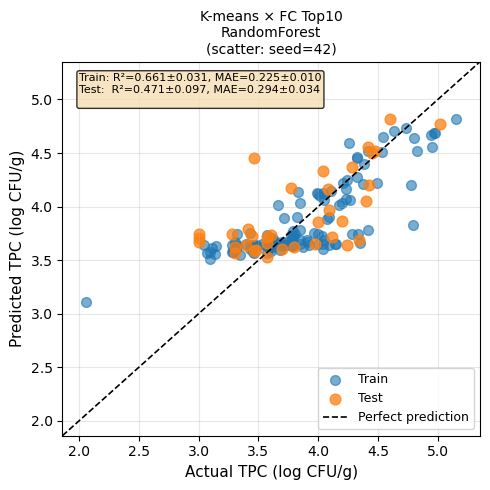

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5mae_cond3_RF_scatter.png


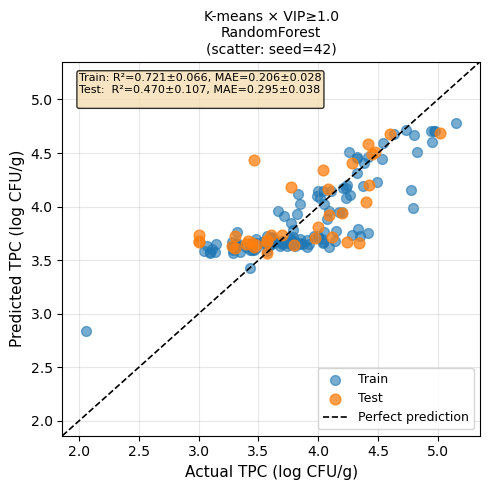

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5mae_cond4_RF_scatter.png


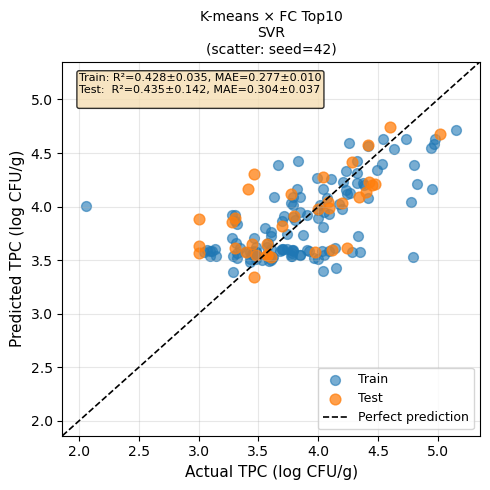

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5mae_cond3_SVR_scatter.png


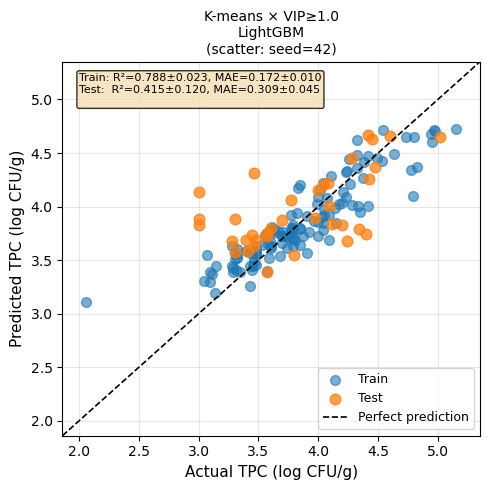

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5mae_cond4_LGB_scatter.png


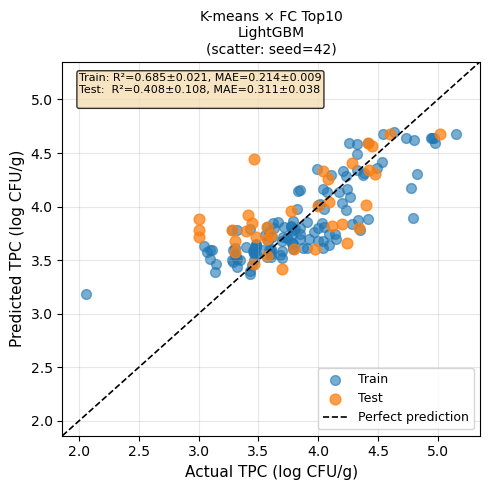

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/top5mae_cond3_LGB_scatter.png


In [7]:
def plot_scatter_single(top5_df, prefix):
    for _, row in top5_df.iterrows():
        cond = row['cond']
        mn   = row['model_name']
        r    = reg_results[cond][mn][LABEL_SEED]

        y_tr   = r['y_train'];   y_tr_p = r['y_train_pred']
        y_te   = r['y_test'];    y_te_p = r['y_test_pred']
        mn_val = min(y_tr.min(), y_te.min()) - 0.2
        mx_val = max(y_tr.max(), y_te.max()) + 0.2

        # ── 10-seed mean±std ──────────────────────────────────────
        tr2s  = [reg_results[cond][mn][s]['train_r2']  for s in SEEDS]
        te2s  = [reg_results[cond][mn][s]['test_r2']   for s in SEEDS]
        tmaes = [reg_results[cond][mn][s]['train_mae'] for s in SEEDS]
        emaes = [reg_results[cond][mn][s]['test_mae']  for s in SEEDS]
        txt = (f"Train: R²={np.mean(tr2s):.3f}±{np.std(tr2s):.3f}, "
               f"MAE={np.mean(tmaes):.3f}±{np.std(tmaes):.3f}\n"
               f"Test:  R²={np.mean(te2s):.3f}±{np.std(te2s):.3f}, "
               f"MAE={np.mean(emaes):.3f}±{np.std(emaes):.3f}\n")

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(y_tr, y_tr_p, color=C_TRAIN, alpha=0.6, s=50, label='Train')
        ax.scatter(y_te, y_te_p, color=C_TEST,  alpha=0.75, s=60, label='Test')
        ax.plot([mn_val, mx_val], [mn_val, mx_val], 'k--', lw=1.2,
                label='Perfect prediction')

        ax.text(0.04, 0.97, txt, transform=ax.transAxes, fontsize=8,
                va='top', 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.8))

        ax.set_xlim(mn_val, mx_val)
        ax.set_ylim(mn_val, mx_val)
        ax.set_xlabel('Actual TPC (log CFU/g)', fontsize=11)
        ax.set_ylabel('Predicted TPC (log CFU/g)', fontsize=11)
        ax.set_title(f"{row['Condition']}\n{mn}\n"
                     f"(scatter: seed={LABEL_SEED})", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()

        fname = f"{prefix}_{cond}_{MODEL_SHORT[mn]}_scatter.png"
        fig.savefig(f"{REG_DIR}/{fname}", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {REG_DIR}/{fname}")

plot_scatter_single(top5_r2,  'top5r2')
plot_scatter_single(top5_mae, 'top5mae')

## 6. Save

| File | Contents |
|---|---|
| `regression_results.pkl` | Full results dictionary (4 conditions × 10 seeds × 5 models) |
| `regression_performance.xlsx` | Performance summary table (mean ± SD) + Top-5 sheets |
| `best_reg_pipeline.pkl` | Best model pipeline from seed-42 (used in `validation.ipynb`) |
| `reg_sensitivity_results.pkl` | R² / MAE results for 10 label seeds × 10 train seeds (Section 11) |

Supplementary figures → `data/reg_scatter/` (saved in Section 10)  
Downstream: `validation.ipynb` loads `best_reg_pipeline.pkl`

In [8]:
from openpyxl.styles import PatternFill

with open(f"{PKL_DIR}/regression_results.pkl", 'wb') as f:
    pickle.dump(reg_results, f)
print(f"PKL saved → {PKL_DIR}/regression_results.pkl")

MODEL_ORDER = ['RandomForest', 'XGBoost', 'SVR', 'LightGBM', 'LSTM']

rows_xl = []
for cond in COND_MAP:
    for mn in MODEL_ORDER:
        if mn not in model_configs:
            continue
        r2s    = [reg_results[cond][mn][s]['test_r2']    for s in SEEDS]
        maes   = [reg_results[cond][mn][s]['test_mae']   for s in SEEDS]
        rmses  = [reg_results[cond][mn][s]['test_rmse']  for s in SEEDS]
        tr2s   = [reg_results[cond][mn][s]['train_r2']   for s in SEEDS]
        tmaes  = [reg_results[cond][mn][s]['train_mae']  for s in SEEDS]
        trmses = [reg_results[cond][mn][s]['train_rmse'] for s in SEEDS]
        bp42   = reg_results[cond][mn][LABEL_SEED]['best_params']

        def fmt(m, s): return f"{m:.4f} ± {s:.4f}"

        rows_xl.append({
            'Condition':          COND_LABELS[cond],
            'Model':              mn,
            'Train MAE':          fmt(np.mean(tmaes),  np.std(tmaes)),
            'Test MAE':           fmt(np.mean(maes),   np.std(maes)),
            'Train RMSE':         fmt(np.mean(trmses), np.std(trmses)),
            'Test RMSE':          fmt(np.mean(rmses),  np.std(rmses)),
            'Train R²':           fmt(np.mean(tr2s),   np.std(tr2s)),
            'Test R²':            fmt(np.mean(r2s),    np.std(r2s)),
            '_test_r2_mean':      np.mean(r2s),
            'Best_Params_seed42': str(bp42),
        })

df_xl = pd.DataFrame(rows_xl)

yellow_fill = PatternFill(start_color='FFFF00', end_color='FFFF00', fill_type='solid')
best_idx = set(df_xl.groupby('Condition')['_test_r2_mean'].idxmax().values)

df_xl = df_xl.drop(columns=['_test_r2_mean'])
xlsx_path = f"{DATA_DIR}/regression_performance.xlsx"

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    df_xl.to_excel(writer, sheet_name='All_Results', index=False)
    top5_r2[['Condition','Model','Test_R2_Mean','Test_R2_Std',
              'Test_MAE_Mean','Test_MAE_Std']].to_excel(
        writer, sheet_name='Top5_by_R2', index=False)
    top5_mae[['Condition','Model','Test_R2_Mean',
               'Test_MAE_Mean','Test_MAE_Std']].to_excel(
        writer, sheet_name='Top5_by_MAE', index=False)

    ws = writer.sheets['All_Results']
    n_cols = df_xl.shape[1]
    for df_row_idx in best_idx:
        for col in range(1, n_cols + 1):
            ws.cell(row=df_row_idx + 2, column=col).fill = yellow_fill

print(f"Excel saved → {xlsx_path}")
print()
print("=== Top 5 by R² ===")
print(top5_r2[['Condition','Model','Test_R2_Mean','Test_MAE_Mean']].to_string(index=False))

PKL saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl/regression_results.pkl
Excel saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/regression_performance.xlsx

=== Top 5 by R² ===
        Condition        Model  Test_R2_Mean  Test_MAE_Mean
 Optuna × VIP≥1.0 RandomForest      0.718555       0.431553
Optuna × FC Top10 RandomForest      0.713128       0.432962
 Optuna × VIP≥1.0      XGBoost      0.710500       0.435306
 Optuna × VIP≥1.0     LightGBM      0.697722       0.450897
 Optuna × VIP≥1.0         LSTM      0.693502       0.450643


## 7. SHAP Analysis — Best Model Selection Rationale

### Selected model: Optuna × FC Top10 × Random Forest

Although Optuna × VIP × RF achieved the highest Test R² = 0.719 across 10 seeds, it showed a Train–Test R² gap (Overfit_R²) = 0.20 (High) and Test R² std = ±0.061, indicating marked instability across seeds.

VIP is a supervised feature selection method based on PLS-DA that selects 23 features optimized to the training label structure (Early vs. Intermediate boundary). In Random Forest, each tree randomly subsamples from these 23 features, yielding approximately 2.3× more possible feature subsets than FC Top10 (10 features), which structurally increases the tendency to memorize training variance.

In contrast, FC Top10 × RF achieved Overfit_R² = 0.14 (Caution) and std = ±0.036 — the only combination to fall below the High threshold — with the interaction between 10 features, max_depth = 3, and min_samples_split = 5 structurally suppressing memorization.

Although raw R² marginally favors VIP × RF (0.719 vs. 0.713), Optuna × FC Top10 × RF was selected as the final model on the basis of generalization stability and reproducibility.

Best: Optuna × FC Top10 / RandomForest  |  seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  seed-38 top: Iodobacter
  seed-39 top: Iodobacter
  seed-40 top: Iodobacter
  seed-41 top: Iodobacter
  seed-42 top: Iodobacter
  seed-43 top: Iodobacter
  seed-44 top: Iodobacter
  seed-45 top: Iodobacter
  seed-46 top: Iodobacter
  seed-47 top: Iodobacter
Union features: 12개 (각 seed FC Top10, union 기준)


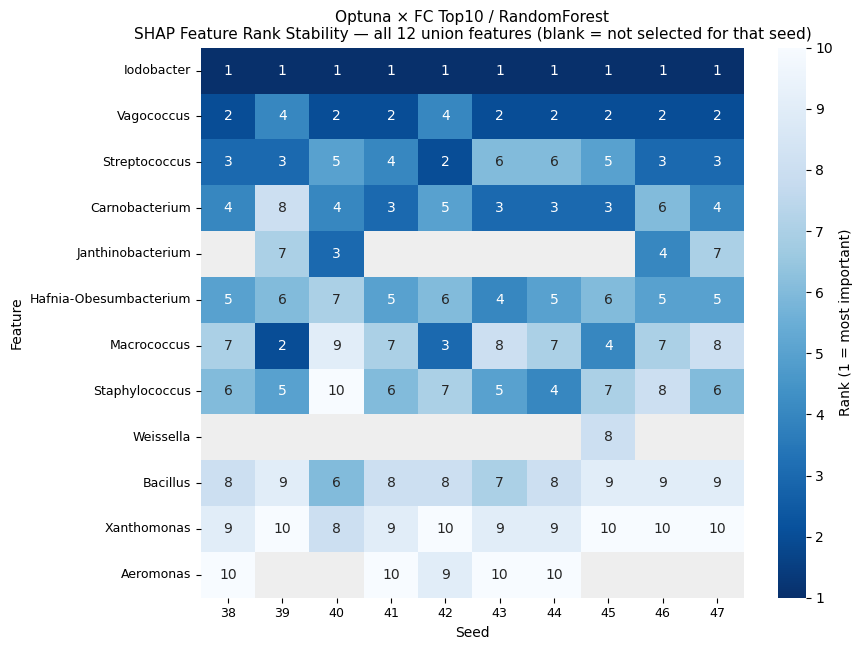

Saved (rank stability): /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_shap/cond1_RF_shap_rank_stability.png


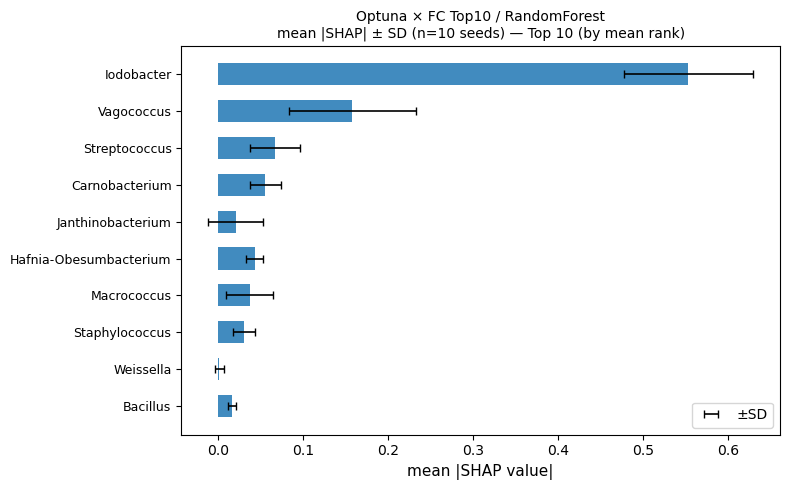

Saved (bar±SD):         /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_shap/cond1_RF_shap_seeds_bar.png


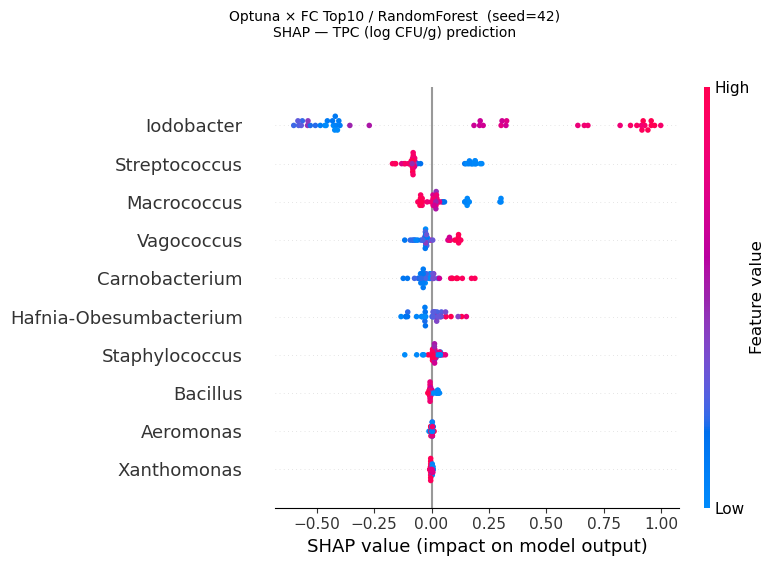

Saved (beeswarm): /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_shap/cond1_RF_shap.png

Best model: Optuna × FC Top10 / RandomForest


In [9]:
import shap
import seaborn as sns

REG_SHAP_DIR = f"{DATA_DIR}/reg_shap"
os.makedirs(REG_SHAP_DIR, exist_ok=True)

# ── Best model 추출 ──────────────────────────────────────────────
bc  = 'cond1'        # Optuna × FC Top10 (과적합 고려 최종 선택)
bm  = 'RandomForest'
bms = MODEL_SHORT[bm]

all_splits = COND_MAP[bc][0]
fkey       = COND_MAP[bc][1]
feat_dict  = screen[fkey]['per_seed_features']
seed_list  = sorted(reg_results[bc][bm].keys())
print(f"Best: {COND_LABELS[bc]} / {bm}  |  seeds: {seed_list}")

# ── Seed별 SHAP importance 수집 ──────────────────────────────────
seed_importance = {}

for seed in seed_list:
    sp    = all_splits[seed]
    feats = feat_dict[seed]
    model = reg_results[bc][bm][seed]['best_model']
    short = [f.replace('g__', '') for f in feats]

    tr_fm = sp['train'][sp['train']['Label'] != 1]
    te_fm = sp['test'][sp['test']['Label'] != 1]
    X_tr  = pd.DataFrame(tr_fm[feats].values, columns=short)
    X_te  = pd.DataFrame(te_fm[feats].values, columns=short)

    inner = None
    if hasattr(model, 'named_steps'):
        inner = model.named_steps.get('svr')
    base = inner if inner else model

    if isinstance(base, LSTMRegressor):
        X_tr_3d    = X_tr.values.reshape(-1, 1, len(feats))
        X_te_3d    = X_te.values.reshape(-1, 1, len(feats))
        background = X_tr_3d[:min(50, len(X_tr_3d))]
        explainer  = shap.DeepExplainer(base.model_, background)
        sv_raw     = explainer.shap_values(X_te_3d)
        if isinstance(sv_raw, list): sv_raw = sv_raw[0]
        shap_vals  = sv_raw[:, 0, :]
    elif isinstance(base, (RandomForestRegressor, XGBRegressor, LGBMRegressor)):
        explainer = shap.TreeExplainer(base)
        shap_vals = explainer.shap_values(X_te)
    else:
        background = shap.sample(X_tr, min(50, len(X_tr)), random_state=seed)
        explainer  = shap.KernelExplainer(model.predict, background)
        shap_vals  = explainer.shap_values(X_te.values, nsamples=100)

    total = np.mean(np.abs(shap_vals), axis=0)
    seed_importance[seed] = {'total': pd.Series(total, index=short)}
    print(f"  seed-{seed} top: {short[np.argmax(total)]}")

# ── Union feature set ─────────────────────────────────────────────
all_feats = sorted({f for s in seed_list for f in seed_importance[s]['total'].index})
print(f"Union features: {len(all_feats)}개 (각 seed FC Top10, union 기준)")

# ── Figure 1: Rank Stability Heatmap ─────────────────────────────
# 각 seed 자기 feature set 내 rank, 미선택 → NaN
display_df = pd.DataFrame(index=all_feats, columns=seed_list, dtype=float)
for s in seed_list:
    imp_own  = seed_importance[s]['total']
    rank_own = imp_own.rank(ascending=False, method='min').astype(int)
    display_df[s] = rank_own.reindex(all_feats)   # 미선택 → NaN

display_df['_sort'] = display_df[seed_list].mean(axis=1)
display_df = display_df.sort_values('_sort').drop(columns='_sort')

annot_df = display_df.copy().astype(object)
for col in annot_df.columns:
    annot_df[col] = annot_df[col].apply(
        lambda x: '' if pd.isna(x) else str(int(x)))

n_feats = len(all_feats)
fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(seed_list)),
                                max(6, 0.55 * n_feats)))
sns.heatmap(display_df,
            annot=annot_df, fmt='', cmap='Blues_r',
            mask=display_df.isna(),
            vmin=1, vmax=10,
            ax=ax, cbar_kws={'label': 'Rank (1 = most important)'})
ax.set_facecolor('#eeeeee')
ax.set_title(f"{COND_LABELS[bc]} / {bm}\n"
             f"SHAP Feature Rank Stability — all {n_feats} union features "
             f"(blank = not selected for that seed)",
             fontsize=11)
ax.set_xlabel('Seed', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.tick_params(labelsize=9)
plt.tight_layout()
rank_path = f"{REG_SHAP_DIR}/{bc}_{bms}_shap_rank_stability.png"
plt.savefig(rank_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved (rank stability): {rank_path}")

# ── Figure 2: bar ± SD (mean rank 상위 10개) ─────────────────────
top10_feats = display_df.index.tolist()[:10]
top_n = len(top10_feats)

imp_mat  = np.array([seed_importance[s]['total'].reindex(top10_feats, fill_value=0.0).values
                     for s in seed_list])
mean_imp = imp_mat.mean(axis=0)
std_imp  = imp_mat.std(axis=0)

y = np.arange(top_n)
fig, ax = plt.subplots(figsize=(8, max(5, 0.45 * top_n)))
ax.barh(y, mean_imp, height=0.6, color='#1f77b4', alpha=0.85)
ax.errorbar(mean_imp, y, xerr=std_imp, fmt='none',
            color='black', capsize=3, linewidth=1.2, label='±SD')
ax.set_yticks(y)
ax.set_yticklabels(top10_feats, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP value|', fontsize=11)
ax.set_title(f"{COND_LABELS[bc]} / {bm}\n"
             f"mean |SHAP| ± SD (n={len(seed_list)} seeds) — Top {top_n} (by mean rank)",
             fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
bar_path = f"{REG_SHAP_DIR}/{bc}_{bms}_shap_seeds_bar.png"
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved (bar±SD):         {bar_path}")

# ── Figure 3: seed-42 beeswarm (논문용 원본) ─────────────────────
sp42    = all_splits[LABEL_SEED]
feats42 = feat_dict[LABEL_SEED]
model42 = reg_results[bc][bm][LABEL_SEED]['best_model']
short42 = [f.replace('g__', '') for f in feats42]

tr_fm42 = sp42['train'][sp42['train']['Label'] != 1]
te_fm42 = sp42['test'][sp42['test']['Label'] != 1]
X_tr42  = pd.DataFrame(tr_fm42[feats42].values, columns=short42)
X_te42  = pd.DataFrame(te_fm42[feats42].values, columns=short42)

inner42 = None
if hasattr(model42, 'named_steps'):
    inner42 = model42.named_steps.get('svr')
base42 = inner42 if inner42 else model42

if isinstance(base42, LSTMRegressor):
    X_tr42_3d   = X_tr42.values.reshape(-1, 1, len(feats42))
    X_te42_3d   = X_te42.values.reshape(-1, 1, len(feats42))
    background  = X_tr42_3d[:min(50, len(X_tr42_3d))]
    explainer   = shap.DeepExplainer(base42.model_, background)
    sv_raw      = explainer.shap_values(X_te42_3d)
    if isinstance(sv_raw, list): sv_raw = sv_raw[0]
    shap_vals42 = sv_raw[:, 0, :]
elif isinstance(base42, (RandomForestRegressor, XGBRegressor, LGBMRegressor)):
    explainer   = shap.TreeExplainer(base42)
    shap_vals42 = explainer.shap_values(X_te42)
else:
    background  = shap.sample(X_tr42, min(50, len(X_tr42)), random_state=LABEL_SEED)
    explainer   = shap.KernelExplainer(model42.predict, background)
    shap_vals42 = explainer.shap_values(X_te42.values, nsamples=100)

shap.summary_plot(shap_vals42, X_te42, show=False, plot_type='dot', color_bar=True)
plt.gcf().suptitle(
    f"{COND_LABELS[bc]} / {bm}  (seed={LABEL_SEED})\n"
    f"SHAP — TPC (log CFU/g) prediction",
    fontsize=10, y=1.02)
plt.tight_layout()
beeswarm_path = f"{REG_SHAP_DIR}/{bc}_{bms}_shap.png"
plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved (beeswarm): {beeswarm_path}")

print(f"\nBest model: {COND_LABELS[bc]} / {bm}")

## 8. Save pipeline 

In [10]:
# ── Regression best model pipeline 저장 ─────────────────────────
_feats = screen[COND_MAP[bc][1]]['per_seed_features'][LABEL_SEED]
_model = reg_results[bc][bm][LABEL_SEED]['best_model']

reg_pipeline = {
    'condition':   bc,
    'cond_label':  COND_LABELS[bc],
    'model_name':  bm,
    'seed':        LABEL_SEED,
    'features':    _feats,
    'model':       _model,
    'tpc_col':     tpc_col,
    'splits_pkl':  'labeled_splits.pkl',
}
with open(f"{PKL_DIR}/best_reg_pipeline.pkl", 'wb') as f:
    pickle.dump(reg_pipeline, f)
print(f"Saved → {PKL_DIR}/best_reg_pipeline.pkl")
print(f"  Condition : {reg_pipeline['cond_label']}")
print(f"  Model     : {bm}  (seed={LABEL_SEED})")
print(f"  Features  : {_feats}")

Saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl/best_reg_pipeline.pkl
  Condition : Optuna × FC Top10
  Model     : RandomForest  (seed=42)
  Features  : ['g__Iodobacter', 'g__Carnobacterium', 'g__Vagococcus', 'g__Hafnia-Obesumbacterium', 'g__Bacillus', 'g__Macrococcus', 'g__Streptococcus', 'g__Xanthomonas', 'g__Staphylococcus', 'g__Aeromonas']


## 9. Figure — Best Model per Condition (Main Paper)

One algorithm selected per condition (Cond 1–4) based on highest Test R².
Actual vs. Predicted scatter plots saved individually using the seed-42 test set.

> Per-seed scatter plots across all 10 seeds → Section 10 (Supplementary)

=== Condition별 Best Model (Test R² 기준) ===
         Condition        Model  Test_R2_Mean  Test_R2_Std  Test_MAE_Mean  Test_MAE_Std
 Optuna × FC Top10 RandomForest      0.713128     0.036156       0.432962      0.038643
  Optuna × VIP≥1.0 RandomForest      0.718555     0.061167       0.431553      0.055544
K-means × FC Top10 RandomForest      0.471106     0.097416       0.293639      0.034351
 K-means × VIP≥1.0 RandomForest      0.469786     0.106774       0.294811      0.037671


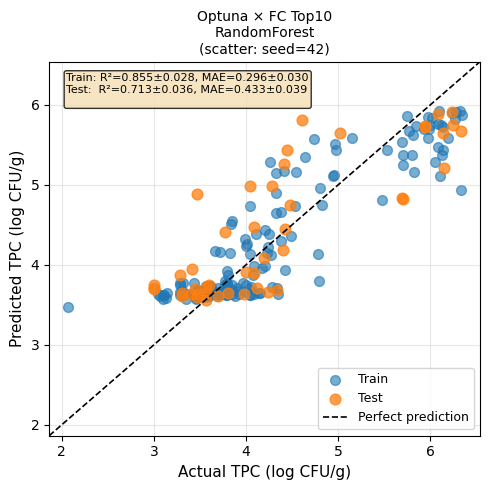

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/fig_cond_best_cond1_RF_scatter.png


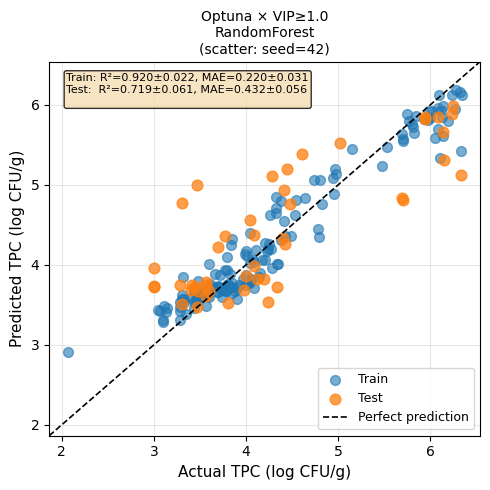

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/fig_cond_best_cond2_RF_scatter.png


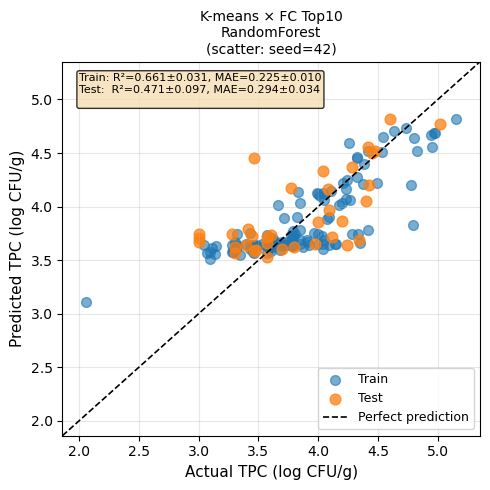

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/fig_cond_best_cond3_RF_scatter.png


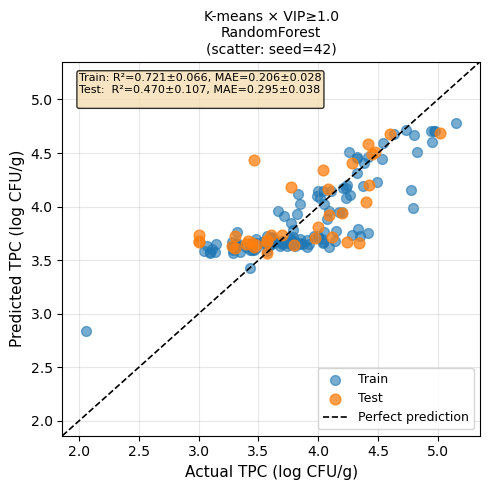

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/fig_cond_best_cond4_RF_scatter.png


In [11]:
# ── Condition별 Test R² 기준 best model 1개씩 ─────────────────────
best_rows = []
for cond in ['cond1', 'cond2', 'cond3', 'cond4']:
    cond_df = df_rank[df_rank['cond'] == cond]
    best_rows.append(cond_df.nlargest(1, 'Test_R2_Mean').iloc[0])

fig_best_df = pd.DataFrame(best_rows).reset_index(drop=True)

print("=== Condition별 Best Model (Test R² 기준) ===")
print(fig_best_df[['Condition', 'Model',
                    'Test_R2_Mean', 'Test_R2_Std',
                    'Test_MAE_Mean', 'Test_MAE_Std']].to_string(index=False))

# ── Scatter Plot ──────────────────────────────────────────────────
plot_scatter_single(fig_best_df, 'fig_cond_best')

## 10. Supplementary — Per-seed Scatter (Best Model)

Based on the best model: Optuna × FC Top10 / Random Forest.
Actual vs. Predicted scatter plots generated from each seed's Early + Intermediate test set across all 10 seeds.

| Item | Description |
|---|---|
| Target | Cond 1 × Random Forest |
| Iterations | Seeds 38–47, one figure per seed |
| Output | `data/reg_scatter/suppl_seed{seed}_scatter.png` |

In [12]:
SUPPL_COND  = 'cond1'
SUPPL_MODEL = 'RandomForest'
suppl_splits = COND_MAP[SUPPL_COND][0]
suppl_fkey   = COND_MAP[SUPPL_COND][1]

for seed in SEEDS:
    model  = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['best_model']
    feats  = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['features']
    y_tr   = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['y_train']
    y_tr_p = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['y_train_pred']
    y_te   = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['y_test']
    y_te_p = reg_results[SUPPL_COND][SUPPL_MODEL][seed]['y_test_pred']

    tr_r2  = r2_score(y_tr, y_tr_p)
    te_r2  = r2_score(y_te, y_te_p)
    tr_mae = mean_absolute_error(y_tr, y_tr_p)
    te_mae = mean_absolute_error(y_te, y_te_p)

    mn_val = min(y_tr.min(), y_te.min()) - 0.2
    mx_val = max(y_tr.max(), y_te.max()) + 0.2

    txt = (f"Train: R²={tr_r2:.3f}, MAE={tr_mae:.3f}\n"
           f"Test:  R²={te_r2:.3f}, MAE={te_mae:.3f}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_tr, y_tr_p, color=C_TRAIN, alpha=0.6, s=50, label='Train')
    ax.scatter(y_te, y_te_p, color=C_TEST,  alpha=0.75, s=60, label='Test')
    ax.plot([mn_val, mx_val], [mn_val, mx_val], 'k--', lw=1.2)
    ax.text(0.04, 0.97, txt, transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.8))
    ax.set_xlim(mn_val, mx_val)
    ax.set_ylim(mn_val, mx_val)
    ax.set_xlabel('Actual TPC (log CFU/g)', fontsize=11)
    ax.set_ylabel('Predicted TPC (log CFU/g)', fontsize=11)
    ax.set_title(
        f"Supplementary — seed={seed}\n"
        f"{COND_LABELS[SUPPL_COND]} / {SUPPL_MODEL}\n"
        f"Early+Intermediate only",
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fname = f"{REG_DIR}/suppl_seed{seed}_scatter.png"
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

print("\nSupplementary scatter 저장 완료.")

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed38_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed39_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed40_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed41_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed42_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed43_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed44_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed45_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed46_scatter.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/reg_scatter/suppl_seed47_scatter.png

Supplementary scatter 저장 완료.
